<a href="https://colab.research.google.com/github/dudaoliani/MVP-CEP-Milk-Quality-Prediction/blob/main/Milk_Quality_Prediction_l_Vers%C3%A3o_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== ETAPA 1: DEFINIR E MEDIR ===
Using Colab cache for faster access to the 'milkquality' dataset.

Estatísticas Descritivas do Processo (Base de Referência):
                pH   Temprature        Taste         Odor         Fat   \
count  1059.000000  1059.000000  1059.000000  1059.000000  1059.000000   
mean      6.630123    44.226629     0.546742     0.432483     0.671388   
std       1.399679    10.098364     0.498046     0.495655     0.469930   
min       3.000000    34.000000     0.000000     0.000000     0.000000   
25%       6.500000    38.000000     0.000000     0.000000     0.000000   
50%       6.700000    41.000000     1.000000     0.000000     1.000000   
75%       6.800000    45.000000     1.000000     1.000000     1.000000   
max       9.500000    90.000000     1.000000     1.000000     1.000000   

         Turbidity       Colour  
count  1059.000000  1059.000000  
mean      0.491029   251.840415  
std       0.500156     4.307424  
min       0.000000   240.000000  
25% 

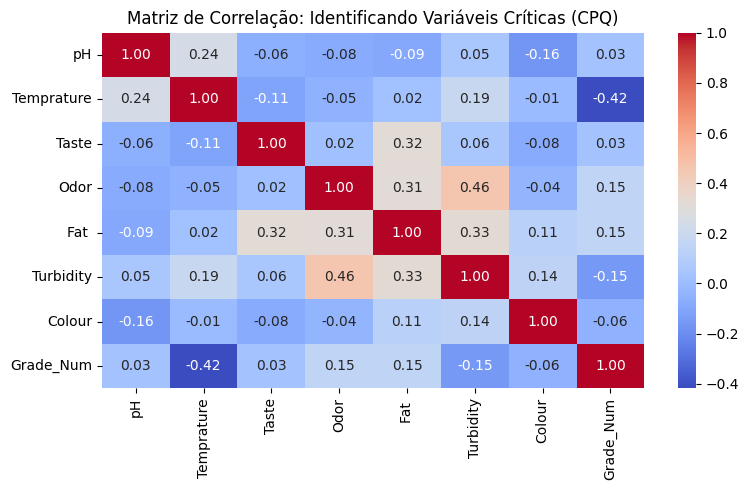


=== ETAPA 3: MELHORAR ===

Relatório de Performance do Classificador de Triagem:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        78
           1       1.00      1.00      1.00        86
           2       0.98      1.00      0.99        48

    accuracy                           1.00       212
   macro avg       0.99      1.00      0.99       212
weighted avg       1.00      1.00      1.00       212



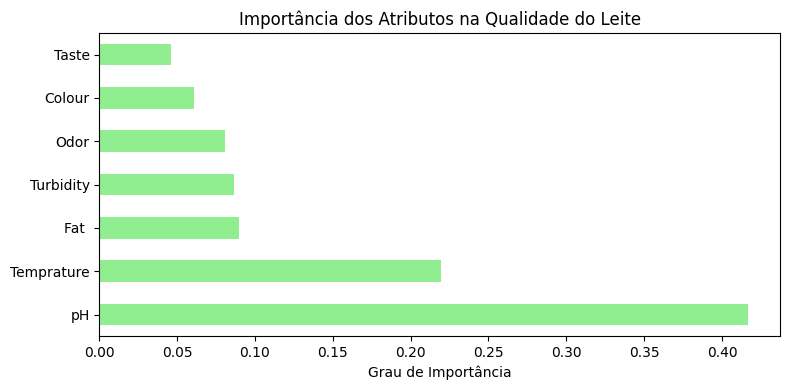


=== ETAPA 4: CONTROLAR ===

Parâmetros Estatísticos Calculados (Fase I):
Média do pH (X-barra): 6.6301
Média das Amplitudes Móveis (MR-barra): 1.4236


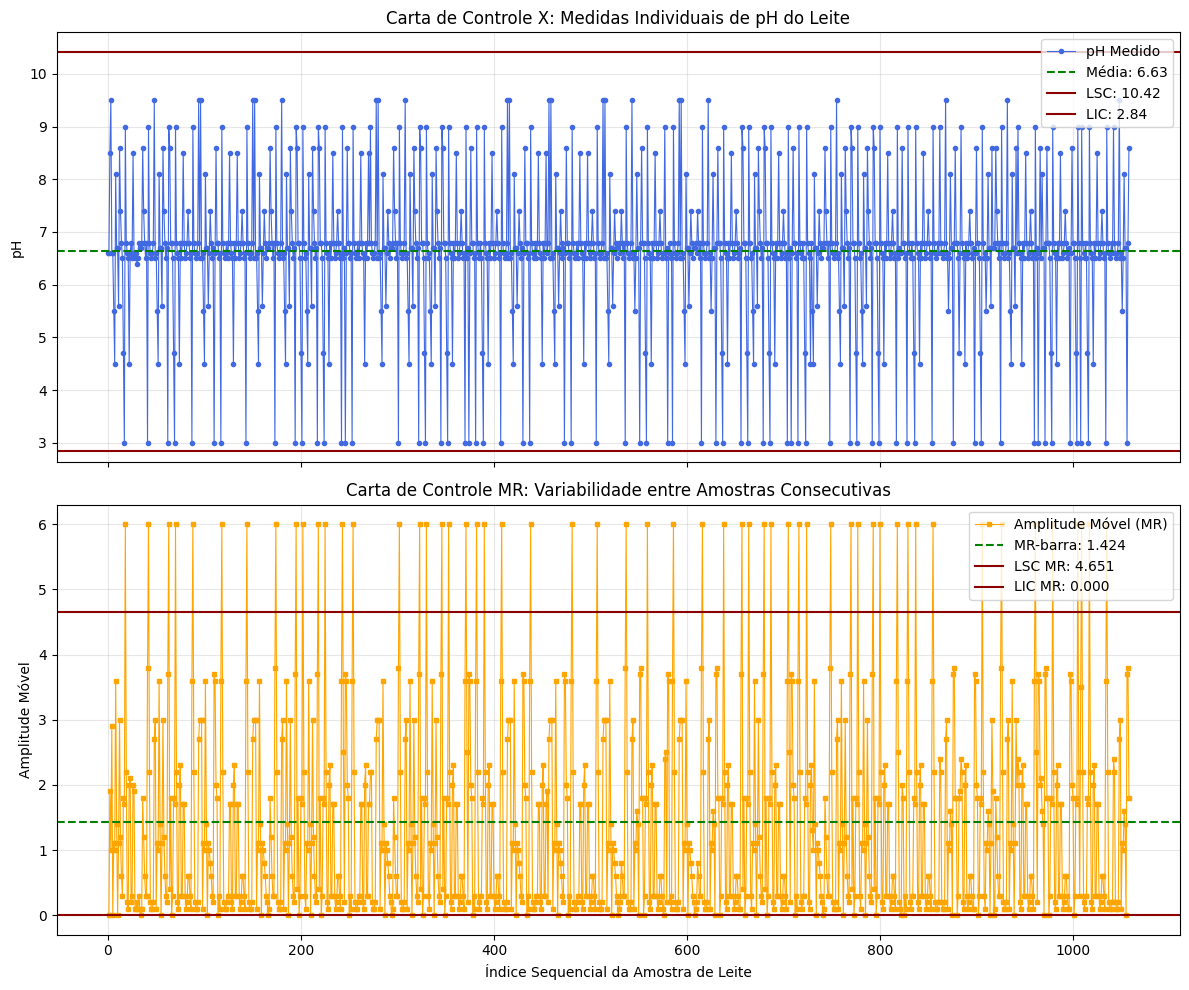


=== DIAGNÓSTICO DE ANOMALIAS (Fase II) ===
 PROCESSO ESTÁVEL: O pH do leite opera sob controle estatístico (apenas causas aleatórias).


In [2]:
# ==============================================================================
# MVP - CONTROLE ESTATÍSTICO DE PROCESSOS (CEP) - VERSÃO COMPLETA E ROBUSTA
# Aluna: Maria Eduarda Moreno Oliani
# Base teórica: D.C. Montgomery - Ciclo DMAMC e Cartas para Variáveis (Cap. 6)
# ==============================================================================

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# ------------------------------------------------------------------------------
# ETAPA 1: DEFINIR E MEDIR (Carga de Dados e Estatística Descritiva)
# ------------------------------------------------------------------------------
print("=== ETAPA 1: DEFINIR E MEDIR ===")
path = kagglehub.dataset_download("cpluzshrijayan/milkquality")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print("\nEstatísticas Descritivas do Processo (Base de Referência):")
print(df.describe())

# ------------------------------------------------------------------------------
# ETAPA 2: ANALISAR (Identificação de Variáveis Críticas - CPQ)
# ------------------------------------------------------------------------------
print("\n=== ETAPA 2: ANALISAR ===")
grade_map = {'low': 0, 'medium': 1, 'high': 2}
df['Grade_Num'] = df['Grade'].map(grade_map)

# Gráfico 1: Matriz de Correlação (Para entender como as variáveis afetam a qualidade)
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matriz de Correlação: Identificando Variáveis Críticas (CPQ)")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# ETAPA 3: MELHORAR (Modelagem Preditiva e Análise de Causa Raiz)
# ------------------------------------------------------------------------------
print("\n=== ETAPA 3: MELHORAR ===")
X = df.drop(['Grade', 'Grade_Num'], axis=1)
y = df['Grade_Num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("\nRelatório de Performance do Classificador de Triagem:")
print(classification_report(y_test, y_pred))

# Gráfico 2: Importância dos Atributos (Equivalente ao Princípio de Pareto para a Causa Raiz)
plt.figure(figsize=(8, 4))
importances = pd.Series(clf.feature_importances_, index=X.columns)
importances.nlargest(7).plot(kind='barh', color='lightgreen')
plt.title("Importância dos Atributos na Qualidade do Leite")
plt.xlabel("Grau de Importância")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# ETAPA 4: CONTROLAR (CEP por Variáveis - Cartas X-MR de Montgomery)
# ------------------------------------------------------------------------------
print("\n=== ETAPA 4: CONTROLAR ===")
# Conforme o Capítulo 6, usamos dados contínuos (pH) para medições individuais (n=1)
df_cep = df.copy().reset_index()

# Calculando a Amplitude Móvel (Moving Range - MR) para n=2 amostras consecutivas
df_cep['MR'] = df_cep['pH'].diff().abs()

# Linhas Centrais
X_bar = df_cep['pH'].mean()
MR_bar = df_cep['MR'].mean()

# Constantes de Shewhart (Apêndice VI do livro para n=2)
d2 = 1.128
D4 = 3.267

# Limites de Controle para a Carta X (Medidas Individuais)
lsc_X = X_bar + 3 * (MR_bar / d2)
lic_X = X_bar - 3 * (MR_bar / d2)

# Limites de Controle para a Carta MR (Amplitude Móvel)
lsc_MR = D4 * MR_bar
lic_MR = 0

print(f"\nParâmetros Estatísticos Calculados (Fase I):")
print(f"Média do pH (X-barra): {X_bar:.4f}")
print(f"Média das Amplitudes Móveis (MR-barra): {MR_bar:.4f}")

# Gráficos 3 e 4: Cartas de Controle Individuais (X-MR) recomendadas no Capítulo 6
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Carta X
ax1.plot(df_cep['pH'], marker='o', linestyle='-', color='royalblue', markersize=3, linewidth=0.8, label='pH Medido')
ax1.axhline(X_bar, color='green', linestyle='--', label=f'Média: {X_bar:.2f}')
ax1.axhline(lsc_X, color='darkred', linestyle='-', label=f'LSC: {lsc_X:.2f}')
ax1.axhline(lic_X, color='darkred', linestyle='-', label=f'LIC: {lic_X:.2f}')
ax1.set_title('Carta de Controle X: Medidas Individuais de pH do Leite')
ax1.set_ylabel('pH')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Carta MR
ax2.plot(df_cep['MR'], marker='s', linestyle='-', color='orange', markersize=3, linewidth=0.8, label='Amplitude Móvel (MR)')
ax2.axhline(MR_bar, color='green', linestyle='--', label=f'MR-barra: {MR_bar:.3f}')
ax2.axhline(lsc_MR, color='darkred', linestyle='-', label=f'LSC MR: {lsc_MR:.3f}')
ax2.axhline(lic_MR, color='darkred', linestyle='-', label=f'LIC MR: {lic_MR:.3f}')
ax2.set_title('Carta de Controle MR: Variabilidade entre Amostras Consecutivas')
ax2.set_ylabel('Amplitude Móvel')
ax2.set_xlabel('Índice Sequencial da Amostra de Leite')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# ETAPA 5: DIAGNÓSTICO E PLANO DE AÇÃO (PAFC)
# ------------------------------------------------------------------------------
print("\n=== DIAGNÓSTICO DE ANOMALIAS (Fase II) ===")
# Identifica pontos que violaram os limites reais de especificação estatística
anomalias_pH = df_cep[(df_cep['pH'] > lsc_X) | (df_cep['pH'] < lic_X)]['index'].tolist()

if len(anomalias_pH) > 0:
    print(f" INSTABILIDADE DETECTADA: {len(anomalias_pH)} amostras apresentaram pH fora dos limites de controle.")
    print(f"Primeiros índices com desvios: {anomalias_pH[:5]}...")
    print("PAFC (Plano de Ação): Interromper recebimento desses lotes, calibrar potenciômetros e checar acidez titulável.")
else:
    print(" PROCESSO ESTÁVEL: O pH do leite opera sob controle estatístico (apenas causas aleatórias).")